In [1]:
import pandas as pd
import numpy as np

In [2]:
loops_genexp=pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv", sep=",")
loops_genexp

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,H3K4me3_signal,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2
0,0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,...,0.188543,0.024018,0.5773,0.0494,NaN,NaN,NaN,NaN,NaN,NaN
1,1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,...,0.566125,0.063427,0.6135,0.0578,NaN,NaN,NaN,NaN,NaN,NaN
2,2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,...,0.188543,0.044699,0.6525,0.0102,NaN,NaN,NaN,NaN,NaN,NaN
3,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,...,0.188543,0.024769,0.6002,0.0948,NaN,NaN,NaN,NaN,NaN,NaN
4,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,...,0.188543,0.042592,0.5949,0.0842,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,...,0.188543,0.026824,0.4545,0.0226,-0.064836,-0.140925,0.270996,0.177009,-0.076090,-0.093987
32273,32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,...,0.249019,0.130330,0.4609,0.0026,0.120802,-0.100746,0.270996,0.177009,-0.221548,-0.093987
32274,32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,...,0.241160,0.123878,0.4195,0.0854,0.270996,0.177009,0.409095,0.332632,-0.093987,-0.076464
32275,32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,...,0.214433,0.112741,0.3788,0.0120,-1.192141,-1.204536,-1.229772,-1.167283,-0.012394,0.062489


In [3]:
# easy func
def compartment_switch(ctrl, rbp1):
    mask = ctrl.notna() & rbp1.notna()
    return mask & (np.sign(ctrl) != np.sign(rbp1))

In [4]:
# For anchor 1
loops_genexp["switch_anchor1"] = compartment_switch(
    loops_genexp["E1_anchor1_ctrl"], 
    loops_genexp["E1_anchor1_rbp1"]
)

# For anchor 2
loops_genexp["switch_anchor2"] = compartment_switch(
    loops_genexp["E1_anchor2_ctrl"], 
    loops_genexp["E1_anchor2_rbp1"]
)

In [5]:
loops_genexp["switch_anchor1"].sum()

1150

In [6]:
loops_genexp["switch_anchor2"].sum()

1267

In [7]:
loops_genexp[loops_genexp["switch_anchor1"]]

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,switch_anchor1,switch_anchor2
40,40,chr1,13360000,13365000,chr1,13415000,13420000,shared,NaN,NaN,...,0.4820,0.0300,-0.023484,0.156645,0.151182,0.107264,0.180128,-0.043917,True,False
196,196,chr1,58515000,58520000,chr1,58650000,58655000,shared,0.041367,0.041364,...,0.3831,0.0334,0.064848,-0.005486,0.151449,0.211499,-0.070334,0.060050,True,False
197,197,chr1,58522500,58527500,chr1,59752500,59757500,shared,0.005470,0.005005,...,0.3871,0.0546,0.064848,-0.005486,-0.021645,-0.031670,-0.070334,-0.010025,True,False
208,208,chr1,62842500,62847500,chr1,63142500,63147500,shared,0.012936,0.010701,...,0.3751,0.0630,-0.143154,0.018211,-0.511001,-0.471670,0.161365,0.039331,True,False
263,263,chr1,88742500,88747500,chr1,88872500,88877500,shared,0.022474,0.022010,...,0.3623,0.0302,0.133881,-0.070042,0.070017,0.130180,-0.203923,0.060164,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32259,32259,chrX,70452500,70457500,chrX,70662500,70667500,gained,0.009886,0.022094,...,0.4401,0.1854,0.074520,-0.061493,0.120802,-0.100746,-0.136014,-0.221548,True,True
32260,32260,chrX,101592500,101597500,chrX,101792500,101797500,gained,0.019086,0.025339,...,0.4002,0.1120,0.074520,-0.061493,0.270996,0.177009,-0.136014,-0.093987,True,False
32269,32269,chrY,10792500,10797500,chrY,11292500,11297500,gained,0.002899,0.003135,...,0.4550,0.0144,0.074520,-0.061493,0.270996,0.177009,-0.136014,-0.093987,True,False
32270,32270,chrY,10795000,10800000,chrY,11720000,11725000,gained,0.003257,0.002960,...,0.4155,0.0574,0.074520,-0.061493,0.409095,0.332632,-0.136014,-0.076464,True,False


In [8]:
loops_genexp[loops_genexp["switch_anchor2"]]

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,switch_anchor1,switch_anchor2
42,42,chr1,13672500,13677500,chr1,13952500,13957500,shared,0.016096,0.012948,...,0.4138,0.0200,0.502622,0.466480,-0.021071,0.100116,-0.036143,0.121187,False,True
44,44,chr1,13822500,13827500,chr1,13952500,13957500,shared,0.031263,0.028234,...,0.4433,0.0790,0.333717,0.386900,-0.021071,0.100116,0.053183,0.121187,False,True
217,217,chr1,64682500,64687500,chr1,64822500,64827500,shared,0.012075,0.013026,...,0.3907,0.0030,-0.243874,-0.177128,-0.065265,0.000852,0.066746,0.066117,False,True
228,228,chr1,67532500,67537500,chr1,67842500,67847500,shared,0.008968,0.005555,...,0.4161,0.0250,0.013392,0.076467,-0.097568,0.038894,0.063075,0.136461,False,True
323,323,chr1,110522500,110527500,chr1,110612500,110617500,shared,0.023522,0.025458,...,0.5089,0.0174,0.214912,0.127367,-0.157736,0.079733,-0.087544,0.237469,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32163,32163,chr7,43702500,43707500,chr7,43842500,43847500,gained,0.011000,0.018367,...,0.4394,0.0264,0.025248,0.002288,0.011444,-0.040473,-0.022960,-0.051918,False,True
32188,32188,chr7,133852500,133857500,chr7,133972500,133977500,gained,0.008845,0.014996,...,0.3831,0.0374,0.140209,0.146472,-0.072543,0.001633,0.006263,0.074176,False,True
32230,32230,chr9,33582500,33587500,chr9,38552500,38557500,gained,0.040927,0.032843,...,0.4688,0.0044,-0.120256,-0.077855,0.011444,-0.040473,0.042401,-0.051918,False,True
32238,32238,chr9,89602500,89607500,chr9,89992500,89997500,gained,0.010197,0.014297,...,0.5384,0.0576,-0.075729,0.100637,-0.009707,0.085684,0.176366,0.095390,True,True


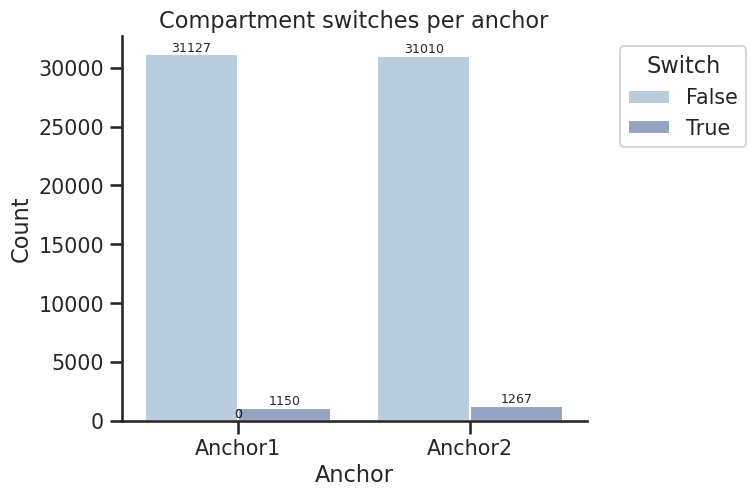

/tmp/ipykernel_3956211/3137544273.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=loops_genexp, x="any_switch", y="log2FC",


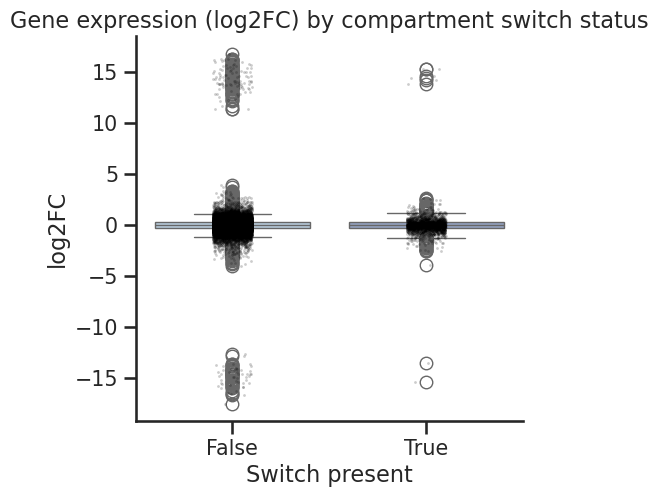

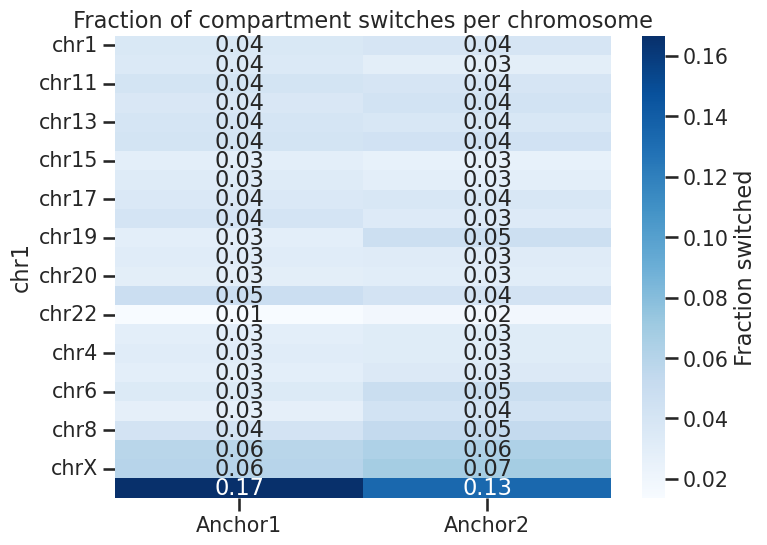

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# === Set style ===
custom_palette = ["#b3cde3", "#8da0cb"]
sns.set_theme(style="ticks", rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context("talk", font_scale=0.9)

# ==========================================================
# 1. Barplot: number of switched vs non-switched anchors
# ==========================================================
switch_counts = pd.DataFrame({
    "Anchor1": loops_genexp["switch_anchor1"].value_counts(),
    "Anchor2": loops_genexp["switch_anchor2"].value_counts()
}).T.reset_index().melt(id_vars="index", var_name="Switch", value_name="Count")

fig, ax = plt.subplots(figsize=(6,5))
sns.barplot(data=switch_counts, x="index", y="Count", hue="Switch", palette=custom_palette, ax=ax)
ax.set_title("Compartment switches per anchor")
ax.set_xlabel("Anchor")
ax.set_ylabel("Count")
ax.legend(title="Switch", bbox_to_anchor=(1.05,1), loc="upper left")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.show()

# ==========================================================
# 2. Boxplot: expression distribution (switched vs non-switched)
# ==========================================================
# Define "any switch" as union of anchor1 and anchor2
loops_genexp["any_switch"] = loops_genexp[["switch_anchor1","switch_anchor2"]].any(axis=1)

fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(data=loops_genexp, x="any_switch", y="log2FC",
            palette=custom_palette, ax=ax)
sns.stripplot(data=loops_genexp, x="any_switch", y="log2FC",
              color="black", alpha=0.2, size=2, ax=ax)
ax.set_title("Gene expression (log2FC) by compartment switch status")
ax.set_xlabel("Switch present")
ax.set_ylabel("log2FC")
plt.show()

# ==========================================================
# 3. Heatmap: fraction of switches per chromosome
# ==========================================================
# Assuming you have "chrom" column
chrom_switch = (loops_genexp.groupby("chr1")[["switch_anchor1","switch_anchor2"]]
                .mean()  # fraction of True per chromosome
                .rename(columns={"switch_anchor1":"Anchor1","switch_anchor2":"Anchor2"}))

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(chrom_switch, cmap="Blues", annot=True, fmt=".2f", cbar_kws={'label': 'Fraction switched'}, ax=ax)
ax.set_title("Fraction of compartment switches per chromosome")
plt.show()


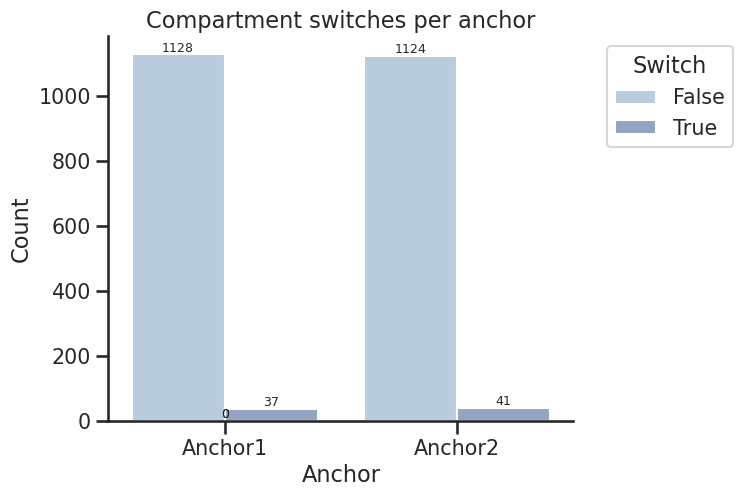

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Prepare data ===
switch_counts = pd.DataFrame({
    "Anchor1": loops_genexp["switch_anchor1"].value_counts(),
    "Anchor2": loops_genexp["switch_anchor2"].value_counts()
}).T.reset_index().melt(id_vars="index", var_name="Switch", value_name="Count")

# Convert Switch to string (avoids 0.00 tick issue)
switch_counts["Switch"] = switch_counts["Switch"].astype(str)

# === Plot ===
custom_palette = ["#b3cde3", "#8da0cb"]

sns.set_theme(style="ticks", rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context("talk", font_scale=0.9)

fig, ax = plt.subplots(figsize=(6,5))
sns.barplot(data=switch_counts, x="index", y="Count", hue="Switch",
            palette=custom_palette, ax=ax)

# Titles and labels
ax.set_title("Compartment switches per anchor")
ax.set_xlabel("Anchor")
ax.set_ylabel("Count")

# Legend
ax.legend(title="Switch", bbox_to_anchor=(1.05,1), loc="upper left")

# Annotate values on bars
for p in ax.patches:
    value = int(p.get_height())
    ax.annotate(value,
                (p.get_x() + p.get_width() / 2., value),
                ha='center', va='bottom', fontsize=9)

plt.show()

/tmp/ipykernel_2742832/1896733512.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df_fc, x="Anchor", y="gene_log2fc", hue="Switch",


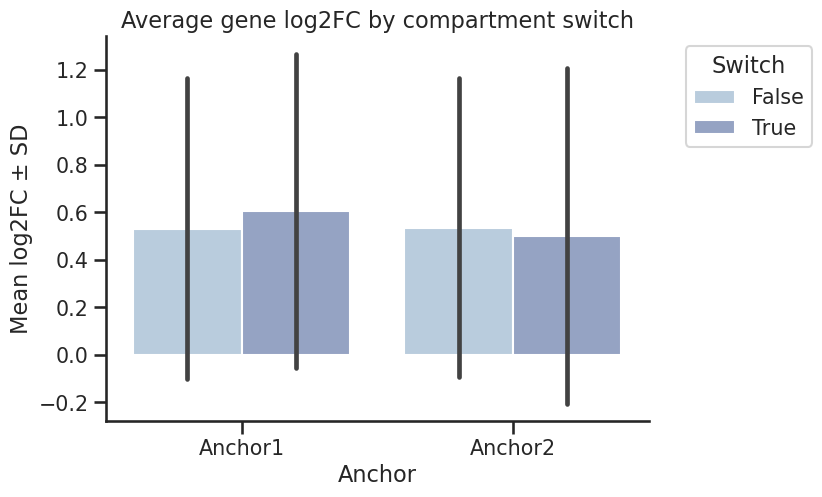

In [14]:
# === Prepare data ===
# Anchor1
df1 = loops_genexp[["switch_anchor1", "gene_log2fc"]].rename(
    columns={"switch_anchor1": "Switch"}
)
df1["Anchor"] = "Anchor1"

# Anchor2
df2 = loops_genexp[["switch_anchor2", "gene_log2fc"]].rename(
    columns={"switch_anchor2": "Switch"}
)
df2["Anchor"] = "Anchor2"

# Combine
df_fc = pd.concat([df1, df2], ignore_index=True)
df_fc["Switch"] = df_fc["Switch"].astype(str)  # avoid numeric 0.0/1.0 issue

# === Plot distributions ===
custom_palette = ["#b3cde3", "#8da0cb"]

sns.set_theme(style="ticks", rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context("talk", font_scale=0.9)

fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(data=df_fc, x="Anchor", y="gene_log2fc", hue="Switch",
            palette=custom_palette, ci="sd", ax=ax)

ax.set_title("Average gene log2FC by compartment switch")
ax.set_xlabel("Anchor")
ax.set_ylabel("Mean log2FC ± SD")
ax.legend(title="Switch", bbox_to_anchor=(1.05,1), loc="upper left")

plt.show()
